# Paths

In [1]:
ROOT_PATH = '../'
MODEL_PATH = '../models'
FIGURE_PATH = '../figures'
DATA_PATH = '../data'
RESULTS_PATH = '../trainig_results'

# Parity Plot

In [2]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
# Load the full dataset (matching your training script)
file_path = os.path.join(DATA_PATH, 'engineered.parquet')
print(f"Loading {file_path}...")
df = pd.read_parquet(file_path)

# 2. Target and Feature Definitions
# Note: Ensure these exclusions match your training code exactly
target = 'eui_target'
raw_target = 'meter_reading'
df['eui_target'] = df['meter_reading'] / df['sqft']

to_exclude = [target, raw_target, 'timestamp', 'location_id', 'building_id', 'site_id', 'is_weekend']
features = [col for col in df.columns if col not in to_exclude]

# 3. Create the Split (using the Time-Based strategy for 'Final' and 'Linear')
# If you are evaluating 'xgboost_model_group_split.pkl', you'll run the Group logic below
time_split = '2017-08-01'

val_mask = df['timestamp'] >= time_split

X_val = df.loc[val_mask, features]
y_val_raw = df.loc[val_mask, raw_target]
sqft_val = df.loc[val_mask, 'sqft'] # Needed to convert EUI back to kWh

print(f"Validation set recreated: {X_val.shape[0]:,} rows.")

Loading ../data\engineered.parquet...
Validation set recreated: 3,721,595 rows.


C:\Users\jlock\AppData\Local\Temp\ipykernel_44276\803230826.py:58: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
C:\Users\jlock\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


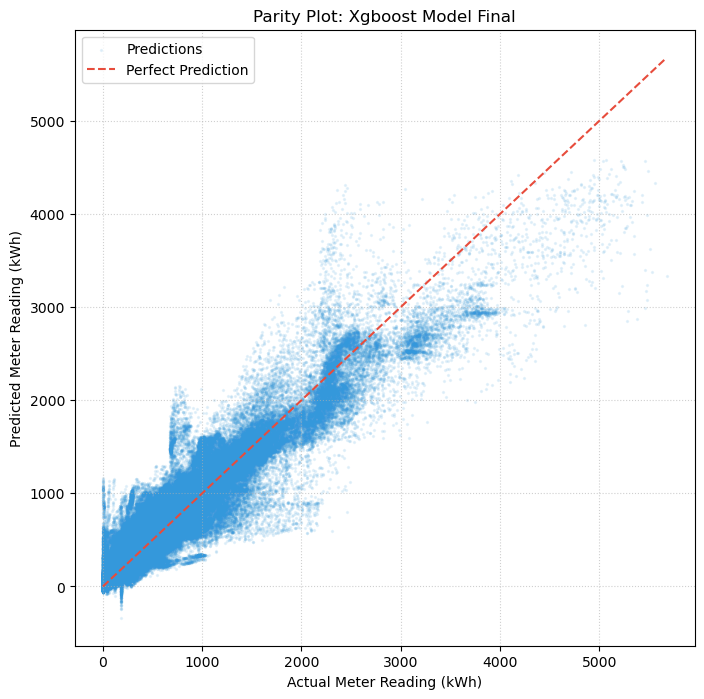

Linear Regression: Applied cat.codes and median imputation.


C:\Users\jlock\AppData\Local\Temp\ipykernel_44276\803230826.py:58: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
C:\Users\jlock\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


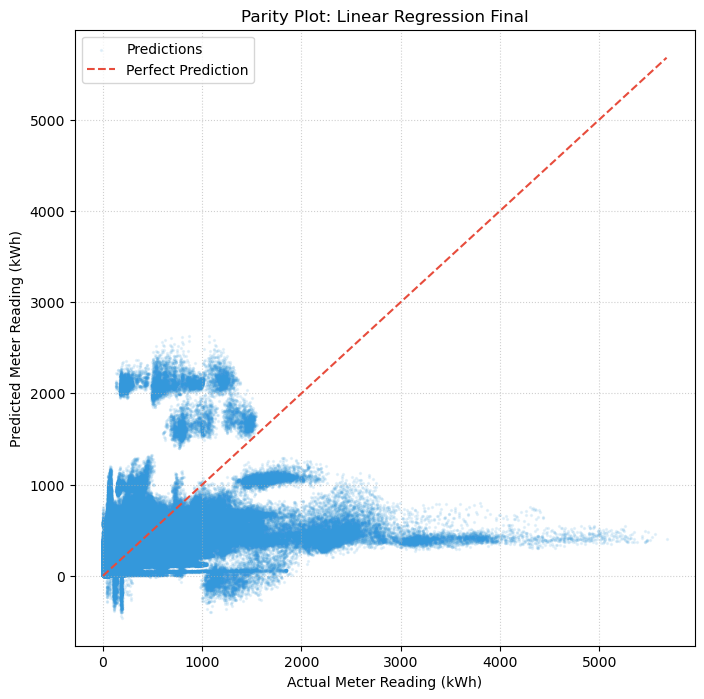

In [3]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

def generate_comparison_plots(model_files, X_data, y_true_raw, sqft_data):
    # Identify categorical columns once for reference
    cat_cols = X_data.select_dtypes(['category']).columns

    for file_name in model_files:
        path = os.path.join(MODEL_PATH, file_name)
        if not os.path.exists(path):
            print(f"File {file_name} not found.")
            continue
            
        model = joblib.load(path)
        
        # --- PREPROCESSING FOR LINEAR REGRESSION ---
        if "linear" in file_name.lower():
            X_eval = X_data.copy()
            
            # 1. Convert categories to codes to match training
            for col in cat_cols:
                X_eval[col] = X_eval[col].cat.codes
            
            # 2. Handle NaNs with median imputation to match training
            # We use the median of the current set for visualization
            X_eval = X_eval.fillna(X_eval.median())
            
            print(f"Linear Regression: Applied cat.codes and median imputation.")
        else:
            # XGBoost handles categories and NaNs natively
            X_eval = X_data

        # 1. Get EUI prediction
        eui_preds = model.predict(X_eval)
        
        # 2. Convert back to raw kWh: kWh = EUI * sqft
        final_preds = eui_preds * sqft_data
        
        # 3. Create Plot
        plt.figure(figsize=(8, 8))
        plt.scatter(y_true_raw, final_preds, alpha=0.1, s=2, color='#3498db', label='Predictions')
        
        # 45-degree Reference Line
        max_val = max(y_true_raw.max(), final_preds.max())
        plt.plot([0, max_val], [0, max_val], color='#e74c3c', linestyle='--', label='Perfect Prediction')
        
        plt.title(f"Parity Plot: {file_name.replace('.pkl', '').replace('_', ' ').title()}")
        plt.xlabel("Actual Meter Reading (kWh)")
        plt.ylabel("Predicted Meter Reading (kWh)")
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.legend()
        
        # Save high-res version for report
        save_path = os.path.join(FIGURE_PATH, f"parity_{file_name.replace('.pkl', '')}.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

# Run the evaluation
generate_comparison_plots(["xgboost_model_final.pkl", "linear_regression_final.pkl"], X_val, y_val_raw, sqft_val)